# 10 — Per-Ticker OHLCV Evaluation Notebook

Evaluation script for the per-ticker TimeGAN models (28 DJIA tickers, 5 features each).

**Protocol:**
- Evaluation in **MinMaxScaled [0,1]** space (same space the generator was trained in)
- Real data: **non-overlapping** windows (stride = `SEQ_LEN`) from HDF5 store
- Matched sample sizes (real = synthetic count)
- Noise distribution: **uniform [0,1]** (matches TimeGAN training)

**Metrics (per-feature where applicable):**
1. Distribution fidelity — MMD (multi-scale RBF), Wasserstein-1, KS test, JS divergence
2. Temporal dynamics — ACF RMSE (returns + squared returns)
3. Geometric distance — Fréchet Distance, DTW
4. Tail behaviour — Mean/Std/Skewness/Kurtosis differences
5. Cross-correlation — Frobenius distance of inter-feature correlation matrices
6. Discriminative score — MLP classifier
7. GRU classifier — Fidelity (accuracy + AUC on 3D sequences)
8. TSTR — Train on Synthetic, Test on Real (usefulness)
9. Entropy — Shannon, Lempel-Ziv, Plug-in (per-feature)
10. Microstructure — Bekker-Parkinson volatility, Corwin-Schultz spread (requires H/L)
11. Visual diagnostics — PCA, t-SNE, sample sequences, distributions, correlation heatmaps

## 0. Configuration

Change this cell to evaluate a different ticker or adjust parameters.

In [1]:
# ============================================================
# PER-TICKER CONFIGURATION — change this block to evaluate a
# different ticker.  Everything downstream is parameterised.
# ============================================================

TICKER           = 'AAPL'      # any of the 28 DJIA tickers
NOISE_TYPE       = 'uniform'   # TimeGAN uses uniform [0,1]
SEQ_LEN          = 24          # sequence length (must match training)
N_FEATURES       = 5           # OHLCV
N_SAMPLES        = 100         # synthetic sequences to generate
FEATURE_NAMES    = ['Open', 'High', 'Low', 'Close', 'Volume']

# --- Paths ---
MODEL_DIR        = f'../time_gan_drl_perticker/{TICKER}'
MODEL_PATH       = f'{MODEL_DIR}/synthetic_data.keras'
HDF_STORE        = '../time_gan_drl_perticker/TimeSeriesGAN_perticker.h5'

MODEL_NAME       = f'Per-Ticker TimeGAN ({TICKER})'

## 1. Imports & Data Loading

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import load_model

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Make utils importable
sys.path.append('..')
import importlib
import utils.evaluation_metrics as _eval_mod
importlib.reload(_eval_mod)
from utils.evaluation_metrics import (
    compute_mmd_per_channel,
    compute_acf_per_channel,
    compute_acf_vectors,
    compute_distribution_per_channel,
    compute_tail_metrics_per_channel,
    compute_cross_correlation_distance,
    compute_discriminative_score,
    compute_frechet_distance,
    compute_dtw_distance,
    compute_js_divergence_3d_dynamic_bins,
    compute_entropy_metrics,
    compute_microstructure_metrics,
)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

2026-03-05 13:30:24.450052: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Load real OHLCV data from HDF5 store
real_df = pd.read_hdf(HDF_STORE, key=f'{TICKER}/real')
print(f"Real data for {TICKER}: {real_df.shape}")
print(f"  Columns: {list(real_df.columns)}")
print(f"  Date range: {real_df.index.min()} → {real_df.index.max()}")
print(real_df.head(3))

# MinMaxScale (same as training)
scaler = MinMaxScaler()
real_scaled = scaler.fit_transform(real_df.values).astype(np.float32)

# --- NON-OVERLAPPING windows (stride = SEQ_LEN) ---
# This avoids inflating sample count with near-duplicate data
n_total = len(real_scaled)
n_windows = n_total // SEQ_LEN
sequences = np.array([
    real_scaled[i * SEQ_LEN : (i + 1) * SEQ_LEN]
    for i in range(n_windows)
], dtype=np.float32)  # shape: (n_windows, SEQ_LEN, N_FEATURES)

print(f"\nTotal trading days: {n_total}")
print(f"Non-overlapping windows (stride={SEQ_LEN}): {sequences.shape}")
print(f"Scaled range: [{sequences.min():.4f}, {sequences.max():.4f}]")

Real data for AAPL: (753, 5)
  Columns: ['open', 'high', 'low', 'close', 'volume']
  Date range: 2021-01-04 00:00:00 → 2023-12-29 00:00:00
              open      high      low   close       volume
date                                                      
2021-01-04  133.52  133.6116  126.760  129.41  158211374.0
2021-01-05  128.89  131.7400  128.430  131.01  105863439.0
2021-01-06  127.72  131.0499  126.382  126.66  165568781.0

Total trading days: 753
Non-overlapping windows (stride=24): (31, 24, 5)
Scaled range: [0.0000, 1.0000]


## 2. Load Generator & Generate Synthetic Data

In [4]:
# Load the per-ticker TimeGAN model (full pipeline: Z → Generator → Supervisor → Recovery)
generator = load_model(MODEL_PATH)
print(f"Loaded generator from {MODEL_PATH}")
print(f"  Input shape:  {generator.input_shape}")
print(f"  Output shape: {generator.output_shape}")
print(f"  Pipeline: Z → Generator → Supervisor → Recovery → X̃  (single .keras)")

# Match sample count to real non-overlapping windows
n_eval = min(N_SAMPLES, len(sequences))

# Generate noise (uniform — matches TimeGAN training)
if NOISE_TYPE == 'uniform':
    Z = tf.random.uniform(shape=(n_eval, SEQ_LEN, N_FEATURES), minval=0.0, maxval=1.0)
elif NOISE_TYPE == 'normal':
    Z = tf.random.normal(shape=(n_eval, SEQ_LEN, N_FEATURES), mean=0.0, stddev=1.0)
else:
    raise ValueError(f"Unknown NOISE_TYPE: {NOISE_TYPE}")

# Generate synthetic data (already in [0,1] scaled space)
synthetic_sequences = generator(Z, training=False).numpy()

# Real data — take first n_eval non-overlapping windows
real_sequences = sequences[:n_eval]  # (n_eval, SEQ_LEN, N_FEATURES)

print(f"\nEvaluation shapes:")
print(f"  Real:      {real_sequences.shape}")
print(f"  Synthetic: {synthetic_sequences.shape}")
print(f"  Noise:     {NOISE_TYPE}, z_dim={N_FEATURES}")

I0000 00:00:1772742626.432159 3595111 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 757 MB memory:  -> device: 0, name: Quadro P620, pci bus id: 0000:01:00.0, compute capability: 6.1


Loaded generator from ../time_gan_drl_perticker/AAPL/synthetic_data.keras
  Input shape:  (None, 24, 5)
  Output shape: (None, 24, 5)
  Pipeline: Z → Generator → Supervisor → Recovery → X̃  (single .keras)

Evaluation shapes:
  Real:      (31, 24, 5)
  Synthetic: (31, 24, 5)
  Noise:     uniform, z_dim=5


2026-03-05 13:30:27.900841: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90600


## 3. Summary Statistics (Sanity Check)

In [5]:
# Quick sanity check before running expensive metrics
# All stats computed in [0,1] scaled space, per feature
rows = []
for f_idx, f_name in enumerate(FEATURE_NAMES):
    r = real_sequences[:, :, f_idx].flatten()
    s = synthetic_sequences[:, :, f_idx].flatten()
    rows.append({
        'Feature': f_name,
        'Real Mean': r.mean(), 'Synth Mean': s.mean(),
        'Real Std': r.std(), 'Synth Std': s.std(),
        'Real Min': r.min(), 'Synth Min': s.min(),
        'Real Max': r.max(), 'Synth Max': s.max(),
        'Δ Mean': s.mean() - r.mean(),
    })

stats = pd.DataFrame(rows).set_index('Feature')
print(f"Summary Statistics (scaled [0,1] space) — {MODEL_NAME}")
print(stats.to_string(float_format='{:.6f}'.format))

# Also show stats in original price space for interpretability
real_rescaled = scaler.inverse_transform(
    real_sequences.reshape(-1, N_FEATURES))
synth_rescaled = scaler.inverse_transform(
    synthetic_sequences.reshape(-1, N_FEATURES))

rows_raw = []
for f_idx, f_name in enumerate(FEATURE_NAMES):
    r = real_rescaled[:, f_idx]
    s = synth_rescaled[:, f_idx]
    rows_raw.append({
        'Feature': f_name,
        'Real Mean': r.mean(), 'Synth Mean': s.mean(),
        'Real Std': r.std(), 'Synth Std': s.std(),
        'Δ Mean': s.mean() - r.mean(),
    })

stats_raw = pd.DataFrame(rows_raw).set_index('Feature')
print(f"\nSummary Statistics (original price space)")
print(stats_raw.to_string(float_format='{:.4f}'.format))

Summary Statistics (scaled [0,1] space) — Per-Ticker TimeGAN (AAPL)
         Real Mean  Synth Mean  Real Std  Synth Std  Real Min  Synth Min  Real Max  Synth Max    Δ Mean
Feature                                                                                                
Open      0.461194    0.441552  0.246555   0.246916  0.000000   0.073414  1.000000   0.852834 -0.019642
High      0.464555    0.440620  0.245932   0.245069  0.000000   0.077767  1.000000   0.848076 -0.023934
Low       0.466124    0.447640  0.241667   0.240638  0.000000   0.077780  1.000000   0.845049 -0.018485
Close     0.480255    0.458213  0.238843   0.235882  0.000000   0.091442  1.000000   0.844778 -0.022042
Volume    0.271124    0.248260  0.137513   0.130531  0.000000   0.047881  1.000000   0.756612 -0.022864

Summary Statistics (original price space)
            Real Mean    Synth Mean      Real Std     Synth Std        Δ Mean
Feature                                                                      
Open 

## 4A. Distribution Fidelity

MMD (multi-scale RBF), Wasserstein-1, KS test, JS divergence — per feature.

In [6]:
# ============================================
# MMD (multi-scale RBF, per-channel)
# ============================================
mmd_results = compute_mmd_per_channel(real_sequences, synthetic_sequences,
                                       num_samples=n_eval)
print(f"MMD (multi-scale RBF, mean): {mmd_results['mean']:.6f}")
for ch, val in mmd_results.items():
    if ch != 'mean':
        print(f"  {ch}: {val:.6f}")

# ============================================
# Wasserstein-1 & KS test
# ============================================
dist_results = compute_distribution_per_channel(real_sequences, synthetic_sequences)
print(f"\nWasserstein-1 (mean): {dist_results['mean_wasserstein']:.6f}")
print(f"KS statistic (mean): {dist_results['mean_ks']:.4f}")
for ch in dist_results['wasserstein']:
    print(f"  {ch}: W={dist_results['wasserstein'][ch]:.6f}, "
          f"KS={dist_results['ks_statistic'][ch]:.4f}, "
          f"p={dist_results['ks_pvalue'][ch]:.4f}")

# ============================================
# JS Divergence
# ============================================
js_similarity = compute_js_divergence_3d_dynamic_bins(real_sequences, synthetic_sequences)
js_divergence = (100 - js_similarity) / 100  # Convert back to [0,1] divergence
print(f"\nJS Divergence: {js_divergence:.6f}")
print(f"JS Similarity: {js_similarity:.2f}%")

MMD (multi-scale RBF, mean): 0.032646
  Open: 0.033568
  High: 0.033214
  Low: 0.032676
  Close: 0.032452
  Volume: 0.031318

Wasserstein-1 (mean): 0.036150
KS statistic (mean): 0.1091
  Open: W=0.041216, KS=0.1129, p=0.0002
  High: W=0.040961, KS=0.1196, p=0.0000
  Low: W=0.038623, KS=0.0968, p=0.0019
  Close: W=0.036911, KS=0.1048, p=0.0006
  Volume: W=0.023037, KS=0.1116, p=0.0002

JS Divergence: 0.276895
JS Similarity: 72.31%


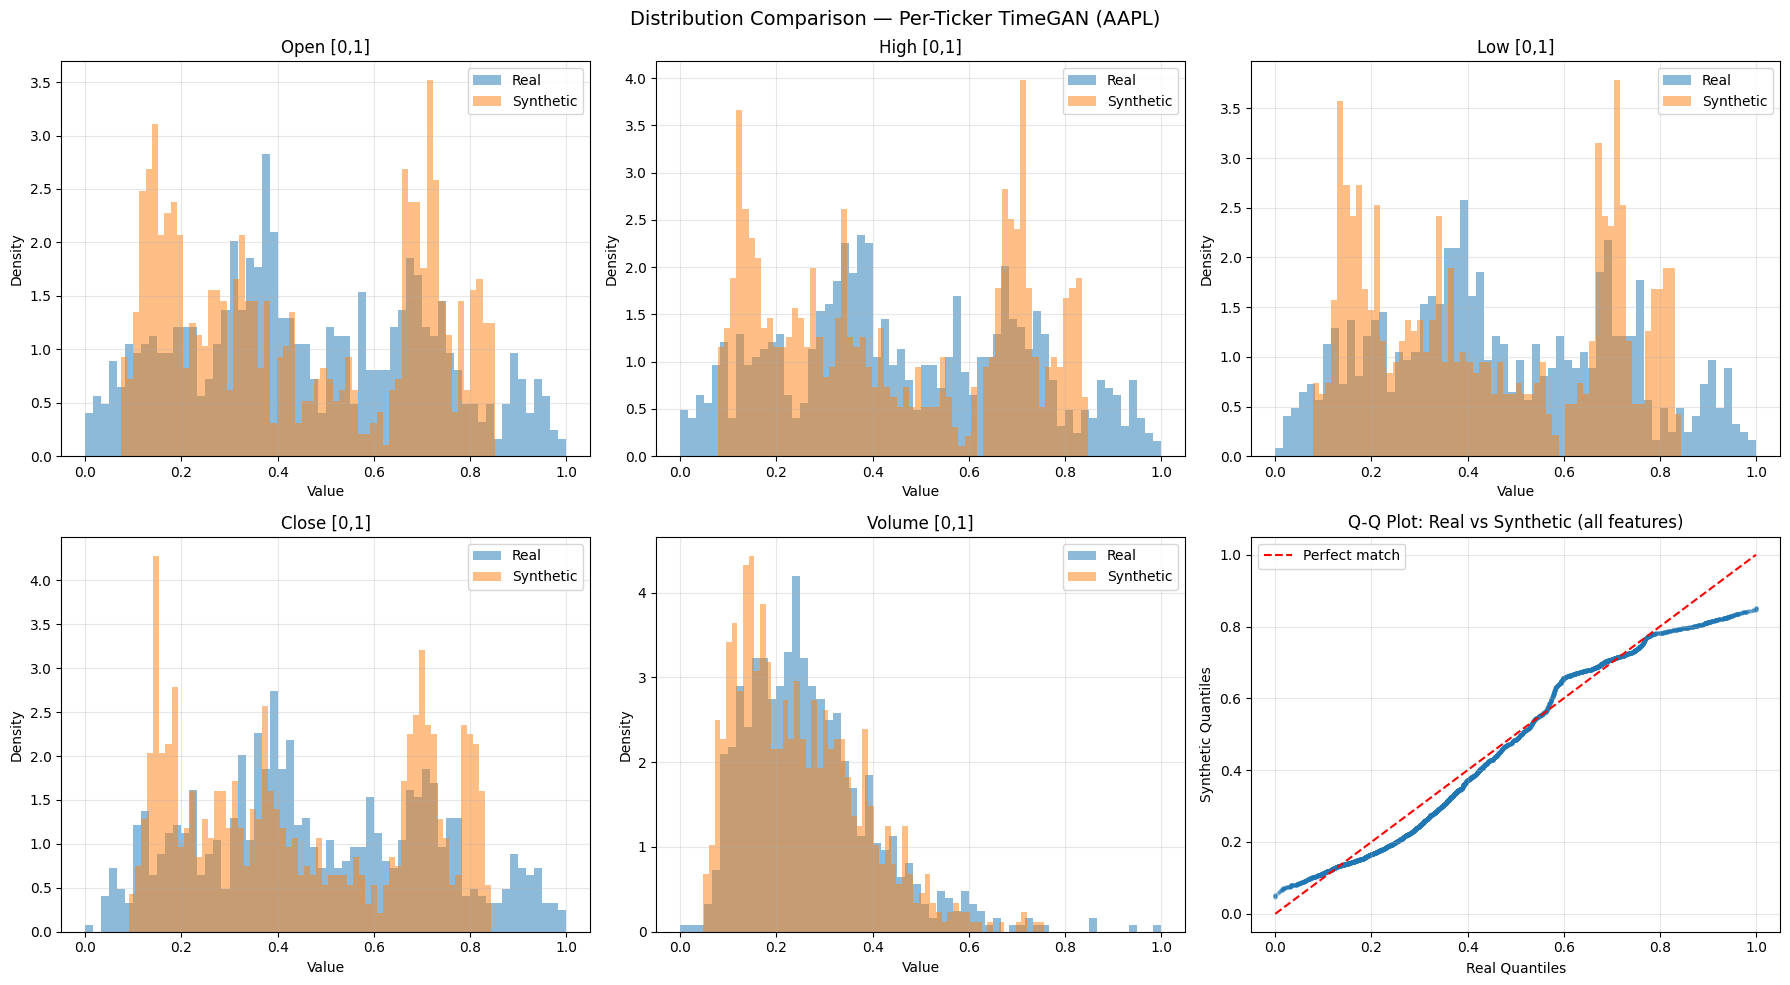

In [7]:
# Distribution plots — histogram per feature (2 rows × 3 cols, last cell for combined)
n_cols = 3
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

for f_idx, f_name in enumerate(FEATURE_NAMES):
    ax = axes[f_idx]
    r = real_sequences[:, :, f_idx].flatten()
    s = synthetic_sequences[:, :, f_idx].flatten()
    ax.hist(r, bins=60, alpha=0.5, density=True, label='Real')
    ax.hist(s, bins=60, alpha=0.5, density=True, label='Synthetic')
    ax.set_title(f'{f_name} [0,1]')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Combined Q-Q plot in last cell
ax = axes[-1]
real_all = real_sequences.reshape(-1)
synth_all = synthetic_sequences.reshape(-1)
real_sorted = np.sort(real_all)
synth_sorted = np.sort(synth_all)
n_qq = min(len(real_sorted), len(synth_sorted))
ax.scatter(
    real_sorted[np.linspace(0, len(real_sorted)-1, n_qq, dtype=int)],
    synth_sorted[np.linspace(0, len(synth_sorted)-1, n_qq, dtype=int)],
    alpha=0.3, s=5
)
ax.plot([0, 1], [0, 1], 'r--', label='Perfect match')
ax.set_title('Q-Q Plot: Real vs Synthetic (all features)')
ax.set_xlabel('Real Quantiles')
ax.set_ylabel('Synthetic Quantiles')
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle(f'Distribution Comparison — {MODEL_NAME}', fontsize=14)
plt.tight_layout()
plt.show()

## 4B. Temporal Dynamics

Autocorrelation RMSE for returns and squared returns (volatility clustering), per feature.

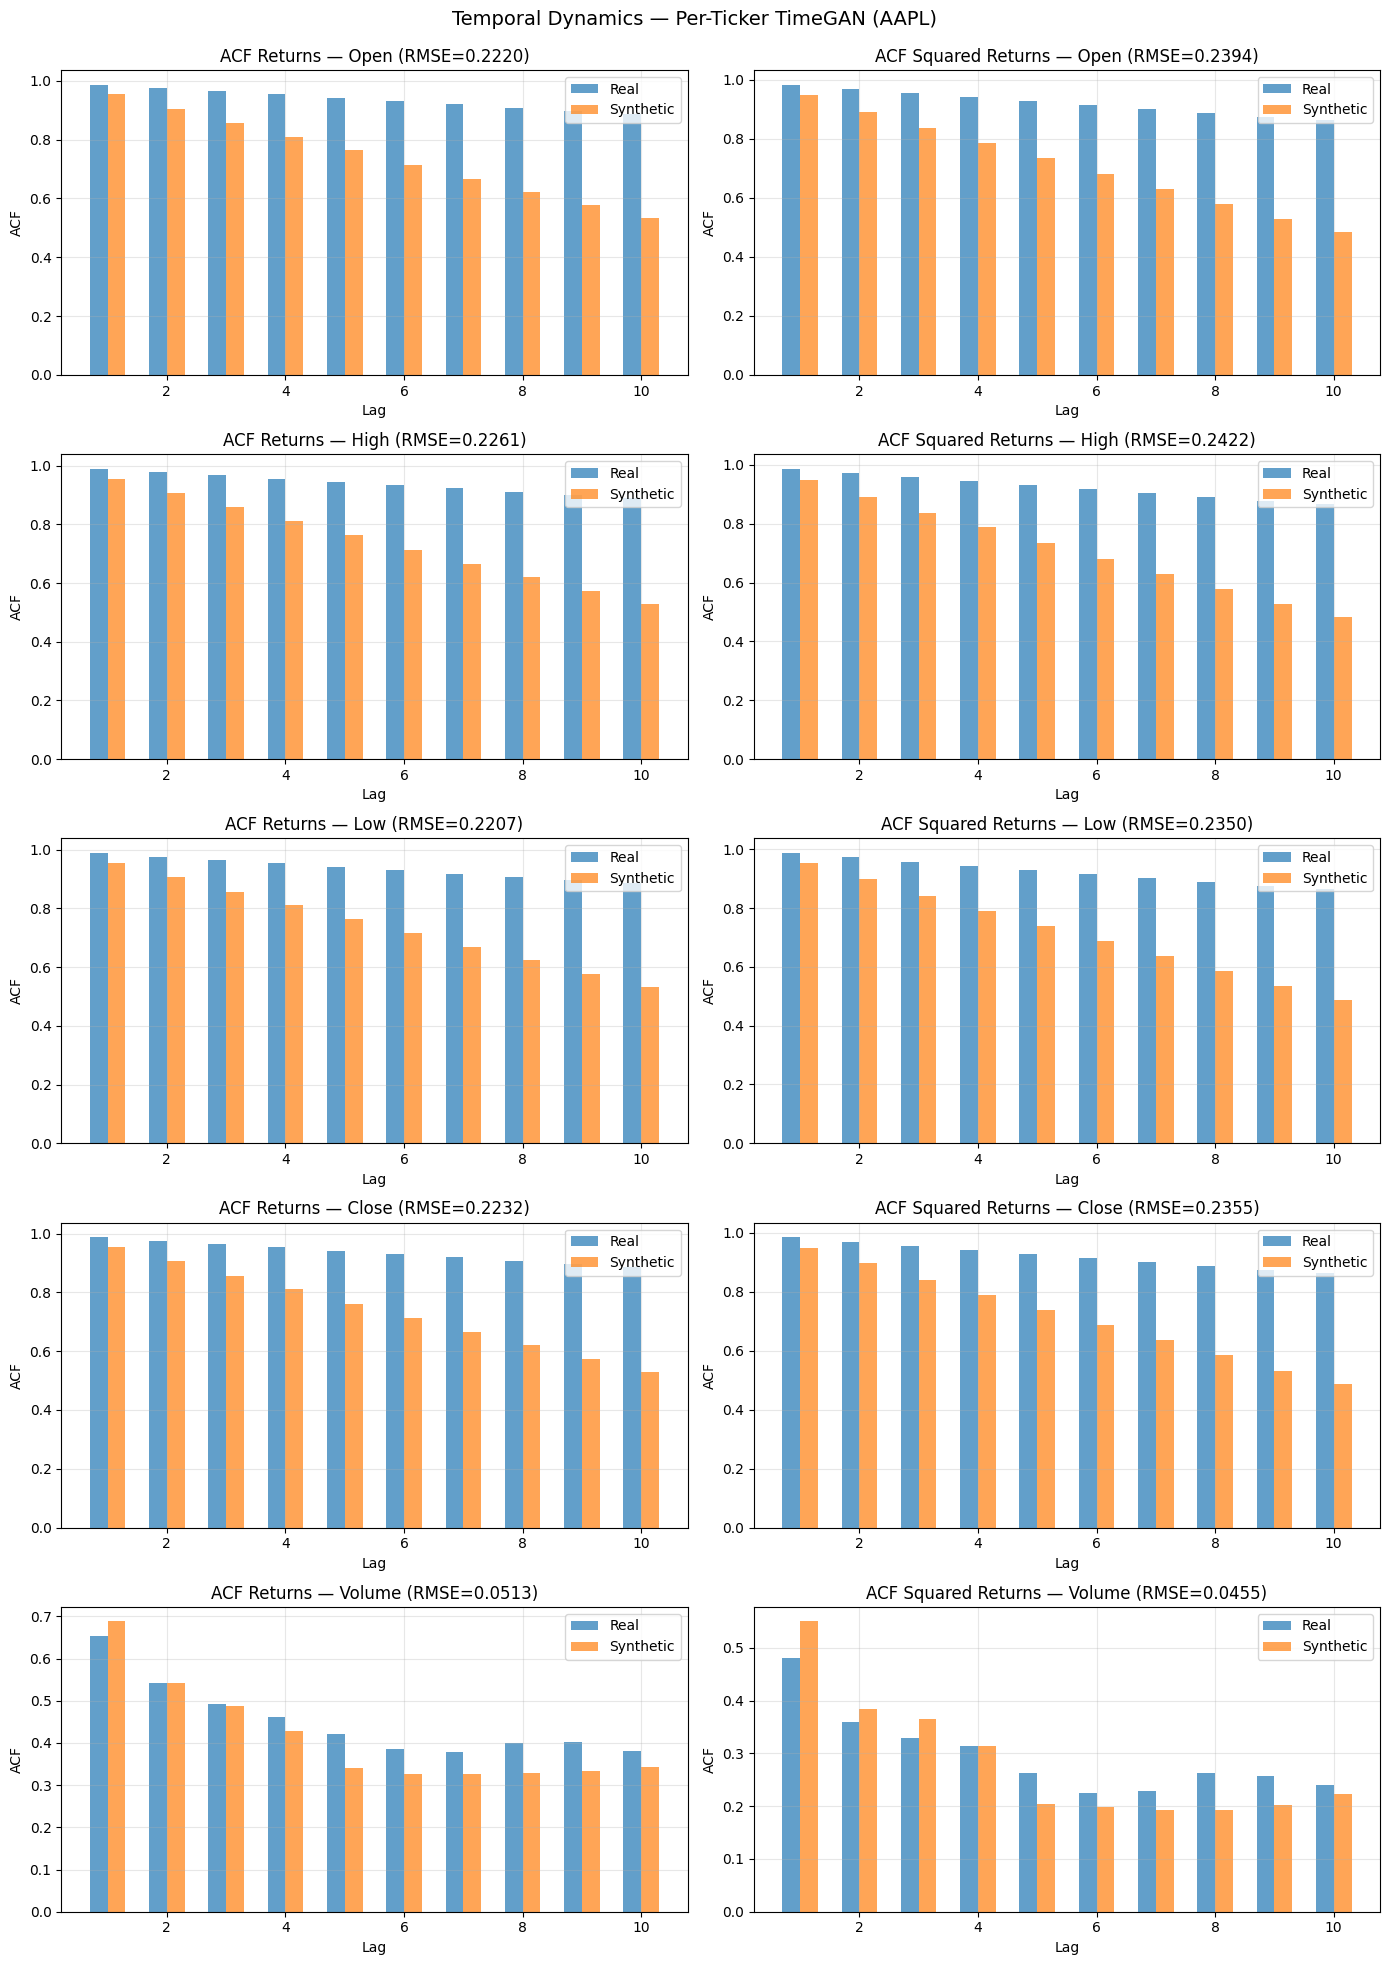

ACF RMSE Summary:
  Open: returns=0.222021, squared=0.239379
  High: returns=0.226084, squared=0.242198
  Low: returns=0.220677, squared=0.235004
  Close: returns=0.223170, squared=0.235492
  Volume: returns=0.051292, squared=0.045488


In [8]:
# ACF comparison — uses compute_acf_vectors for plotting
acf = compute_acf_vectors(real_sequences, synthetic_sequences, max_lag=10)
lags = acf['lags']

# Also get scalar RMSE from compute_acf_per_channel (for summary table later)
acf_rmse_results = compute_acf_per_channel(real_sequences, synthetic_sequences, max_lag=10)

# Plot per feature (2 columns: returns ACF, squared returns ACF)
n_ch = len(acf['returns'])
fig, axes = plt.subplots(n_ch, 2, figsize=(14, 4 * n_ch))
if n_ch == 1:
    axes = axes[np.newaxis, :]

for i, ch_name in enumerate(acf['returns']):
    ret = acf['returns'][ch_name]
    sq = acf['squared'][ch_name]

    axes[i, 0].bar(lags - 0.15, ret['real'], width=0.3, label='Real', alpha=0.7)
    axes[i, 0].bar(lags + 0.15, ret['synthetic'], width=0.3, label='Synthetic', alpha=0.7)
    axes[i, 0].set_title(f'ACF Returns — {ch_name} (RMSE={ret["rmse"]:.4f})')
    axes[i, 0].set_xlabel('Lag')
    axes[i, 0].set_ylabel('ACF')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].bar(lags - 0.15, sq['real'], width=0.3, label='Real', alpha=0.7)
    axes[i, 1].bar(lags + 0.15, sq['synthetic'], width=0.3, label='Synthetic', alpha=0.7)
    axes[i, 1].set_title(f'ACF Squared Returns — {ch_name} (RMSE={sq["rmse"]:.4f})')
    axes[i, 1].set_xlabel('Lag')
    axes[i, 1].set_ylabel('ACF')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

fig.suptitle(f'Temporal Dynamics — {MODEL_NAME}', fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

# Print summary
print(f"ACF RMSE Summary:")
for ch_name in acf['returns']:
    print(f"  {ch_name}: returns={acf['returns'][ch_name]['rmse']:.6f}, "
          f"squared={acf['squared'][ch_name]['rmse']:.6f}")

## 4C. Geometric / Embedding Distance

Fréchet Distance (joint + per-channel) and DTW.

In [9]:
# ============================================
# Fréchet Distance (joint, per-channel)
# ============================================
fd_results = compute_frechet_distance(real_sequences, synthetic_sequences, per_channel=True)
print(f"Fréchet Distance (joint):       {fd_results['overall_fd']:.6f}")
print(f"Fréchet Distance (avg channel): {fd_results['average_channel_fd']:.6f}")
for ch, val in fd_results['channel_fd'].items():
    print(f"  {ch}: {val:.6f}")

# ============================================
# DTW Distance (subsampled for speed)
# ============================================
n_dtw = min(50, n_eval)  # DTW is O(n²) per pair — subsample
dtw_real = real_sequences[:n_dtw]
dtw_synth = synthetic_sequences[:n_dtw]
dtw_score = compute_dtw_distance(dtw_real, dtw_synth)
print(f"\nDTW Distance (mean, n={n_dtw}): {dtw_score:.6f}")

Fréchet Distance (joint):       0.003553
Fréchet Distance (avg channel): 0.000474
  Channel_0: 0.000386
  Channel_1: 0.000574
  Channel_2: 0.000343
  Channel_3: 0.000495
  Channel_4: 0.000571

DTW Distance (mean, n=31): 16.764375


## 4D. Tail Behaviour & Higher-Order Statistics

Mean, std, skewness, and kurtosis differences — per feature.  Critical for financial risk modelling.

Tail Metrics — Per-Ticker TimeGAN (AAPL)
Feature             Mean Δ  Std Ratio     Skew Δ     Kurt Δ
-------------------------------------------------------
  Open            0.019642     1.0015     0.0331     0.5902
  High            0.023934     0.9965     0.0209     0.5622
  Low             0.018485     0.9957     0.0781     0.6015
  Close           0.022042     0.9876     0.0661     0.5660
  Volume          0.022864     0.9492     0.4040     2.1494


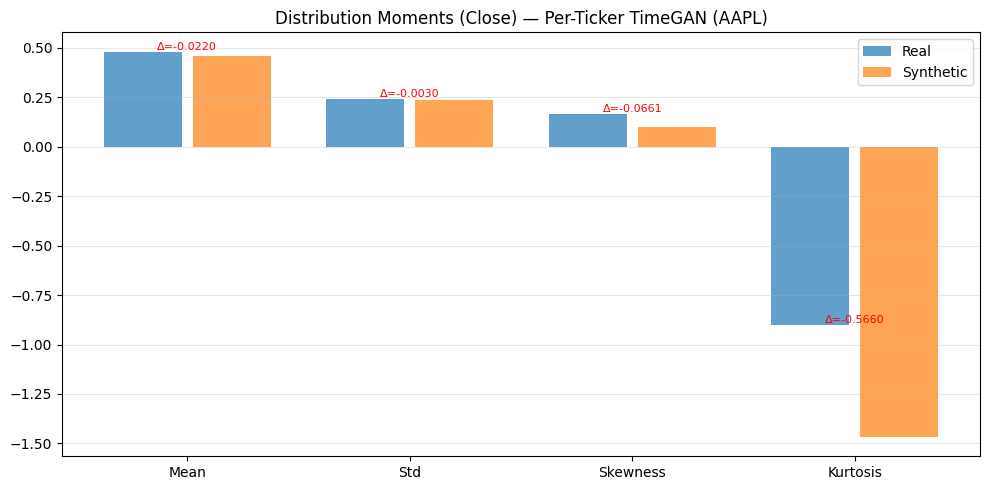

In [10]:
from scipy.stats import skew, kurtosis

tail_results = compute_tail_metrics_per_channel(real_sequences, synthetic_sequences)

print(f"Tail Metrics — {MODEL_NAME}")
print(f"{'Feature':<15} {'Mean Δ':>10} {'Std Ratio':>10} {'Skew Δ':>10} {'Kurt Δ':>10}")
print("-" * 55)
for ch in tail_results['mean_diff']:
    print(f"  {ch:<13} {tail_results['mean_diff'][ch]:>10.6f} "
          f"{tail_results['std_ratio'][ch]:>10.4f} "
          f"{tail_results['skew_diff'][ch]:>10.4f} "
          f"{tail_results['kurtosis_diff'][ch]:>10.4f}")

# Bar chart — real vs synthetic moments (Close feature for interpretability)
close_idx = FEATURE_NAMES.index('Close')
real_close = real_sequences[:, :, close_idx].flatten()
synth_close = synthetic_sequences[:, :, close_idx].flatten()

moment_names = ['Mean', 'Std', 'Skewness', 'Kurtosis']
real_moments = [np.mean(real_close), np.std(real_close),
                skew(real_close), kurtosis(real_close)]
synth_moments = [np.mean(synth_close), np.std(synth_close),
                 skew(synth_close), kurtosis(synth_close)]

x = np.arange(len(moment_names))
fig, ax = plt.subplots(figsize=(10, 5))
bars_r = ax.bar(x - 0.2, real_moments, 0.35, label='Real', alpha=0.7)
bars_s = ax.bar(x + 0.2, synth_moments, 0.35, label='Synthetic', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(moment_names)
ax.set_title(f'Distribution Moments (Close) — {MODEL_NAME}')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Annotate deltas
for i, (r, s) in enumerate(zip(real_moments, synth_moments)):
    delta = s - r
    ax.annotate(f'Δ={delta:.4f}', xy=(i, max(r, s)),
                ha='center', va='bottom', fontsize=8, color='red')

plt.tight_layout()
plt.show()

## 4E. Cross-Correlation Structure

Frobenius distance between real and synthetic inter-feature correlation matrices.  
OHLCV has strong intrinsic correlations (O≈H≈L≈C, Volume decorrelated) — a good generator must preserve this.

Cross-correlation Frobenius distance:    0.626344
Cross-correlation Frobenius (normalised): 0.125269


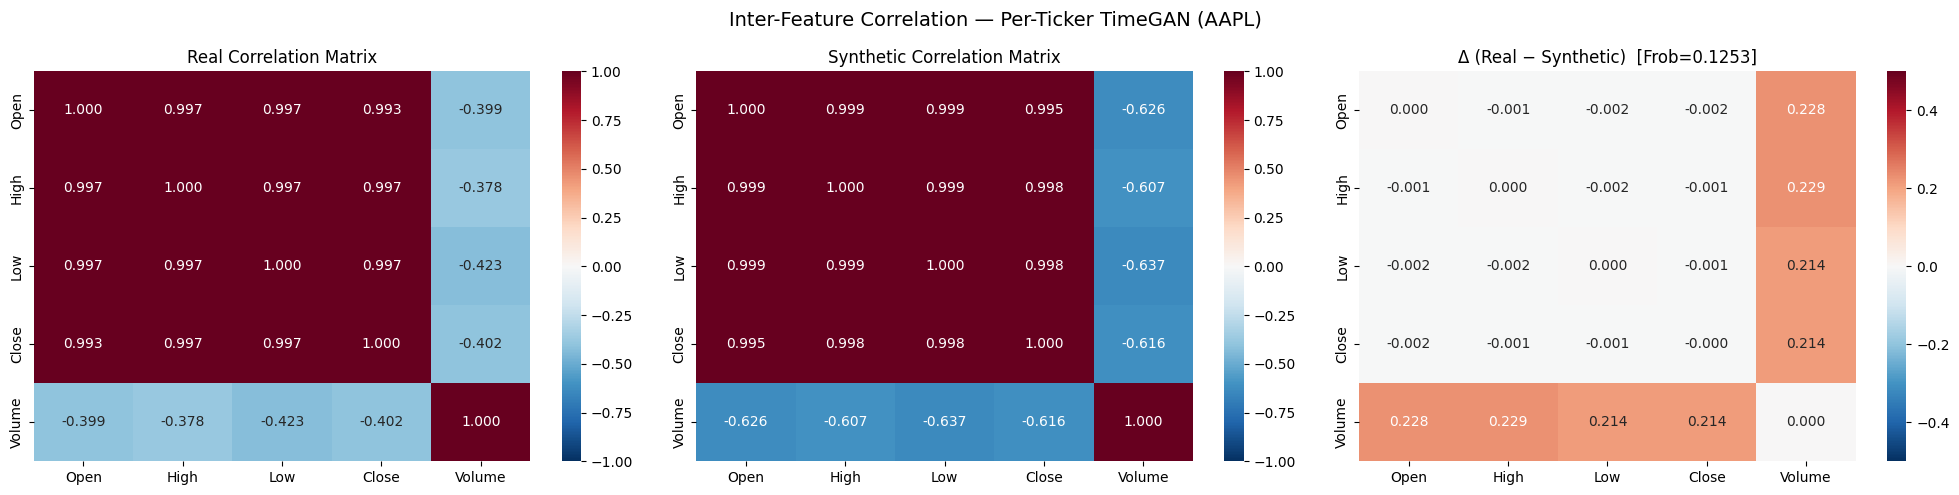

In [11]:
xcorr = compute_cross_correlation_distance(real_sequences, synthetic_sequences)
print(f"Cross-correlation Frobenius distance:    {xcorr['frobenius_distance']:.6f}")
print(f"Cross-correlation Frobenius (normalised): {xcorr['frobenius_normalised']:.6f}")

# Heatmap comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Real correlation matrix
sns.heatmap(xcorr['real_corr'], annot=True, fmt='.3f', cmap='RdBu_r',
            vmin=-1, vmax=1, xticklabels=FEATURE_NAMES, yticklabels=FEATURE_NAMES,
            ax=axes[0])
axes[0].set_title('Real Correlation Matrix')

# Synthetic correlation matrix
sns.heatmap(xcorr['synthetic_corr'], annot=True, fmt='.3f', cmap='RdBu_r',
            vmin=-1, vmax=1, xticklabels=FEATURE_NAMES, yticklabels=FEATURE_NAMES,
            ax=axes[1])
axes[1].set_title('Synthetic Correlation Matrix')

# Difference
diff_corr = xcorr['real_corr'] - xcorr['synthetic_corr']
sns.heatmap(diff_corr, annot=True, fmt='.3f', cmap='RdBu_r',
            vmin=-0.5, vmax=0.5, xticklabels=FEATURE_NAMES, yticklabels=FEATURE_NAMES,
            ax=axes[2])
axes[2].set_title(f'Δ (Real − Synthetic)  [Frob={xcorr["frobenius_normalised"]:.4f}]')

fig.suptitle(f'Inter-Feature Correlation — {MODEL_NAME}', fontsize=14)
plt.tight_layout()
plt.show()

## 4F. Discriminative Score

MLP classifier trained to distinguish real from synthetic.  
Score = |accuracy − 0.5|. Lower = better (indistinguishable).

In [12]:
disc_results = compute_discriminative_score(real_sequences, synthetic_sequences)
print(f"Discriminative Accuracy: {disc_results['accuracy']:.4f}")
print(f"Discriminative Score:    {disc_results['score']:.4f}  (closer to 0 = better)")

Discriminative Accuracy: 0.6923
Discriminative Score:    0.1923  (closer to 0 = better)


/opt/synthetic-financial-data/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


## 4G. GRU Classifier — Fidelity Assessment

A GRU-based time series classifier trained to distinguish real from synthetic
sequences on the **full 3D data** (preserving temporal structure).  
Adapted from the original TimeGAN evaluation (Yoon et al. 2019).

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Input
from tensorflow.keras.metrics import AUC
from matplotlib.ticker import FuncFormatter

# --- Prepare labelled dataset (3D) ---
n_series = n_eval
idx = np.arange(n_series)
n_train = int(0.8 * n_series)
train_idx, test_idx = idx[:n_train], idx[n_train:]

train_data = np.vstack((real_sequences[train_idx], synthetic_sequences[train_idx]))
test_data  = np.vstack((real_sequences[test_idx],  synthetic_sequences[test_idx]))

n_train_cls, n_test_cls = len(train_idx), len(test_idx)
train_labels = np.concatenate([np.ones(n_train_cls), np.zeros(n_train_cls)])
test_labels  = np.concatenate([np.ones(n_test_cls),  np.zeros(n_test_cls)])

# --- Build GRU classifier ---
gru_classifier = Sequential([
    Input(shape=(SEQ_LEN, N_FEATURES)),
    GRU(24, name='GRU'),
    Dense(1, activation='sigmoid', name='OUT')
], name='TS_Classifier')

gru_classifier.compile(loss='binary_crossentropy',
                       optimizer='adam',
                       metrics=[AUC(name='AUC'), 'accuracy'])

gru_result = gru_classifier.fit(
    x=train_data, y=train_labels,
    validation_data=(test_data, test_labels),
    epochs=250, batch_size=128, verbose=0
)

gru_test_loss, gru_test_auc, gru_test_acc = gru_classifier.evaluate(
    test_data, test_labels, verbose=0
)
gru_disc_score = abs(0.5 - gru_test_acc)

print(f"GRU Classifier — Test Accuracy: {gru_test_acc:.4f}, "
      f"AUC: {gru_test_auc:.4f}, Score: {gru_disc_score:.4f}")

# --- Plot training curves ---
history = pd.DataFrame(gru_result.history)
fig, axes = plt.subplots(ncols=2, figsize=(14, 4))

history[['accuracy', 'val_accuracy']].rename(
    columns={'accuracy': 'Train', 'val_accuracy': 'Test'}
).plot(ax=axes[0], title='Accuracy', style=['-', '--'], xlim=(0, 250))
axes[0].set_xlabel('Epoch')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].set_ylabel('Accuracy (%)')

history[['AUC', 'val_AUC']].rename(
    columns={'AUC': 'Train', 'val_AUC': 'Test'}
).plot(ax=axes[1], title='ROC Area under the Curve',
       style=['-', '--'], xlim=(0, 250))
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')

sns.despine()
fig.suptitle(f'Fidelity: GRU Time Series Classification — {MODEL_NAME}', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.85)
plt.show()

KeyboardInterrupt: 

## 4H. TSTR — Train on Synthetic, Test on Real (Usefulness)

Train a GRU regression model to predict the next time step (all 5 features).  
Compare: model trained on **synthetic** vs model trained on **real** data,  
both tested on held-out real data.  If the synthetic-trained model performs  
comparably, the synthetic data is *useful* for downstream ML tasks.

TSTR MAE (Train Synthetic, Test Real): 0.056193
TRTR MAE (Train Real, Test Real):      0.080627
TSTR / TRTR ratio:                     0.6970  (closer to 1.0 = better)


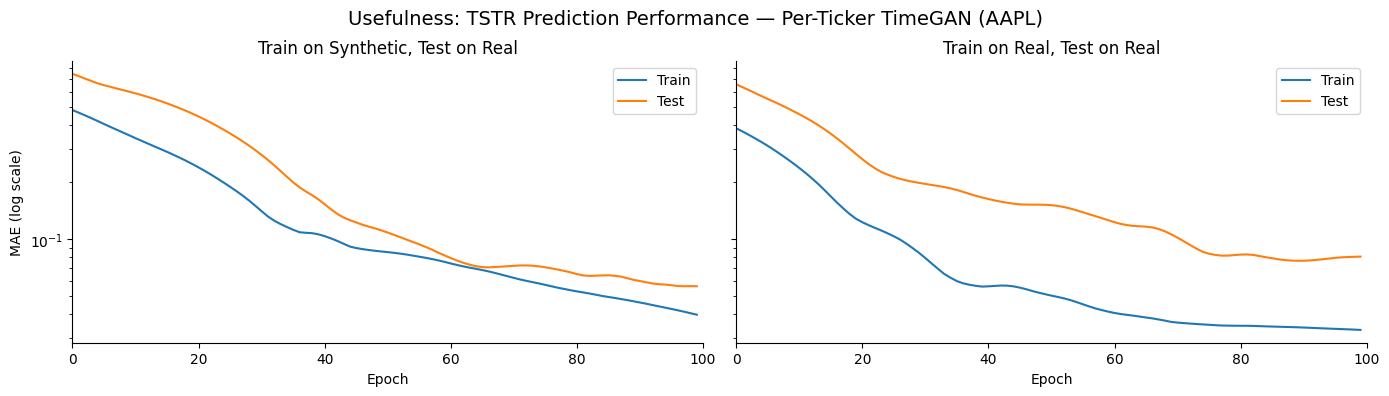

In [ ]:
from tensorflow.keras.losses import MeanAbsoluteError
from tensorflow.keras.optimizers import Adam

# --- Split sequences: input = t[0:-1], label = t[-1] ---
real_train_X = real_sequences[train_idx, :-1, :]   # (n_train, SEQ_LEN-1, N_FEATURES)
real_train_y = real_sequences[train_idx, -1, :]     # (n_train, N_FEATURES)
real_test_X  = real_sequences[test_idx, :-1, :]
real_test_y  = real_sequences[test_idx, -1, :]

synth_train_X = synthetic_sequences[:, :-1, :]      # use all synthetic for training
synth_train_y = synthetic_sequences[:, -1, :]

def build_predictor():
    model = Sequential([
        Input(shape=(SEQ_LEN - 1, N_FEATURES)),
        GRU(24),
        Dense(N_FEATURES)
    ])
    model.compile(optimizer=Adam(), loss=MeanAbsoluteError(name='MAE'))
    return model

# --- Train on Synthetic, Test on Real ---
tstr_model = build_predictor()
tstr_result = tstr_model.fit(
    x=synth_train_X, y=synth_train_y,
    validation_data=(real_test_X, real_test_y),
    epochs=100, batch_size=128, verbose=0
)
tstr_mae = tstr_model.evaluate(real_test_X, real_test_y, verbose=0)

# --- Train on Real, Test on Real (baseline) ---
trtr_model = build_predictor()
trtr_result = trtr_model.fit(
    x=real_train_X, y=real_train_y,
    validation_data=(real_test_X, real_test_y),
    epochs=100, batch_size=128, verbose=0
)
trtr_mae = trtr_model.evaluate(real_test_X, real_test_y, verbose=0)

print(f"TSTR MAE (Train Synthetic, Test Real): {tstr_mae:.6f}")
print(f"TRTR MAE (Train Real, Test Real):      {trtr_mae:.6f}")
print(f"TSTR / TRTR ratio:                     {tstr_mae / trtr_mae:.4f}  (closer to 1.0 = better)")

# --- Plot training curves ---
tstr_hist = pd.DataFrame(tstr_result.history).rename(columns={'loss': 'Train', 'val_loss': 'Test'})
trtr_hist = pd.DataFrame(trtr_result.history).rename(columns={'loss': 'Train', 'val_loss': 'Test'})

fig, axes = plt.subplots(ncols=2, figsize=(14, 4), sharey=True)
tstr_hist.plot(ax=axes[0], title='Train on Synthetic, Test on Real',
               logy=True, xlim=(0, 100))
trtr_hist.plot(ax=axes[1], title='Train on Real, Test on Real',
               logy=True, xlim=(0, 100))
for i in [0, 1]:
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('MAE (log scale)')

sns.despine()
fig.suptitle(f'Usefulness: TSTR Prediction Performance — {MODEL_NAME}', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.85)
plt.show()

## 5. Visual Diagnostics

PCA, t-SNE, and sample sequence comparison.

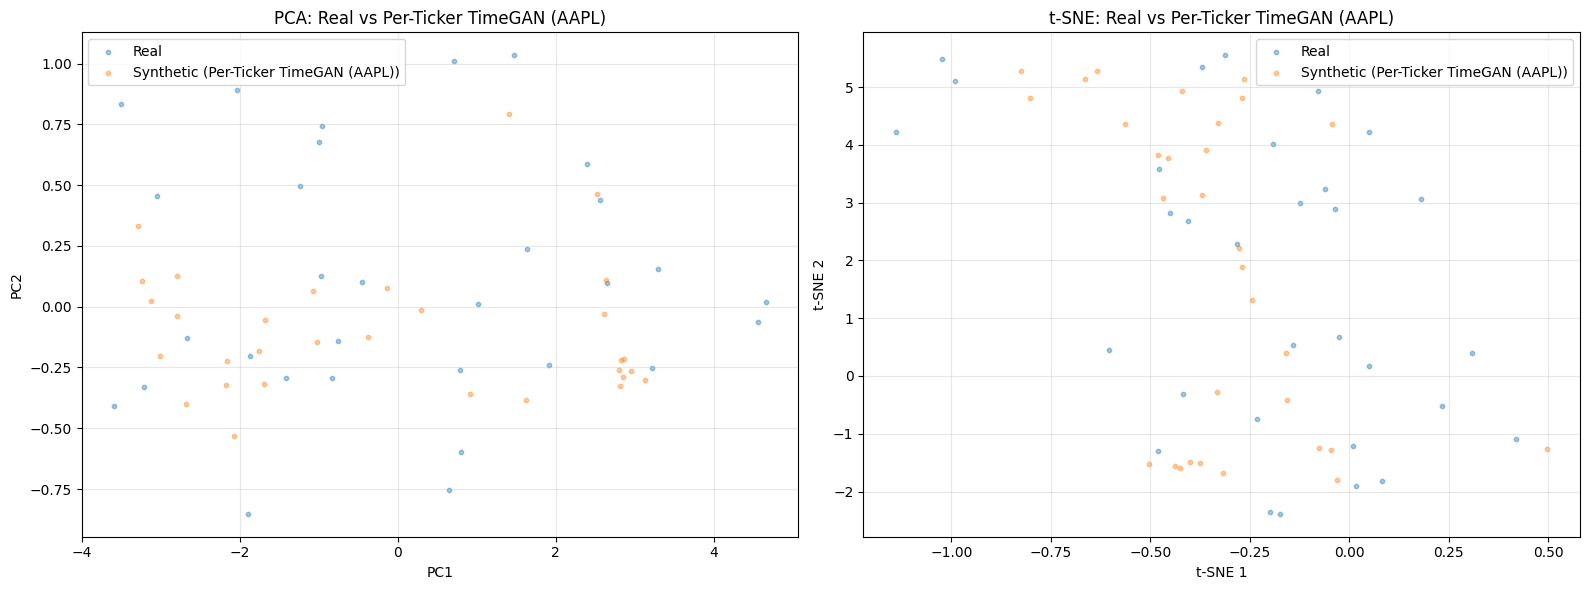

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Flatten to 2D: (n_eval, SEQ_LEN * N_FEATURES) for embedding
real_2d = real_sequences.reshape(n_eval, -1)
synth_2d = synthetic_sequences.reshape(n_eval, -1)
combined = np.vstack([real_2d, synth_2d])
labels = np.array([0] * n_eval + [1] * n_eval)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(combined)
axes[0].scatter(pca_result[labels==0, 0], pca_result[labels==0, 1],
                alpha=0.4, label='Real', s=10)
axes[0].scatter(pca_result[labels==1, 0], pca_result[labels==1, 1],
                alpha=0.4, label=f'Synthetic ({MODEL_NAME})', s=10)
axes[0].set_title(f'PCA: Real vs {MODEL_NAME}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# t-SNE (subsample for speed)
n_tsne = min(500, n_eval)
idx_real = np.random.choice(n_eval, n_tsne, replace=n_tsne > n_eval)
idx_synth = np.random.choice(n_eval, n_tsne, replace=n_tsne > n_eval) + n_eval
idx_all = np.concatenate([idx_real, idx_synth])

tsne = TSNE(n_components=2, perplexity=min(30, n_tsne - 1), random_state=42)
tsne_result = tsne.fit_transform(combined[idx_all])
tsne_labels = labels[idx_all]

axes[1].scatter(tsne_result[tsne_labels==0, 0], tsne_result[tsne_labels==0, 1],
                alpha=0.4, label='Real', s=10)
axes[1].scatter(tsne_result[tsne_labels==1, 0], tsne_result[tsne_labels==1, 1],
                alpha=0.4, label=f'Synthetic ({MODEL_NAME})', s=10)
axes[1].set_title(f't-SNE: Real vs {MODEL_NAME}')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

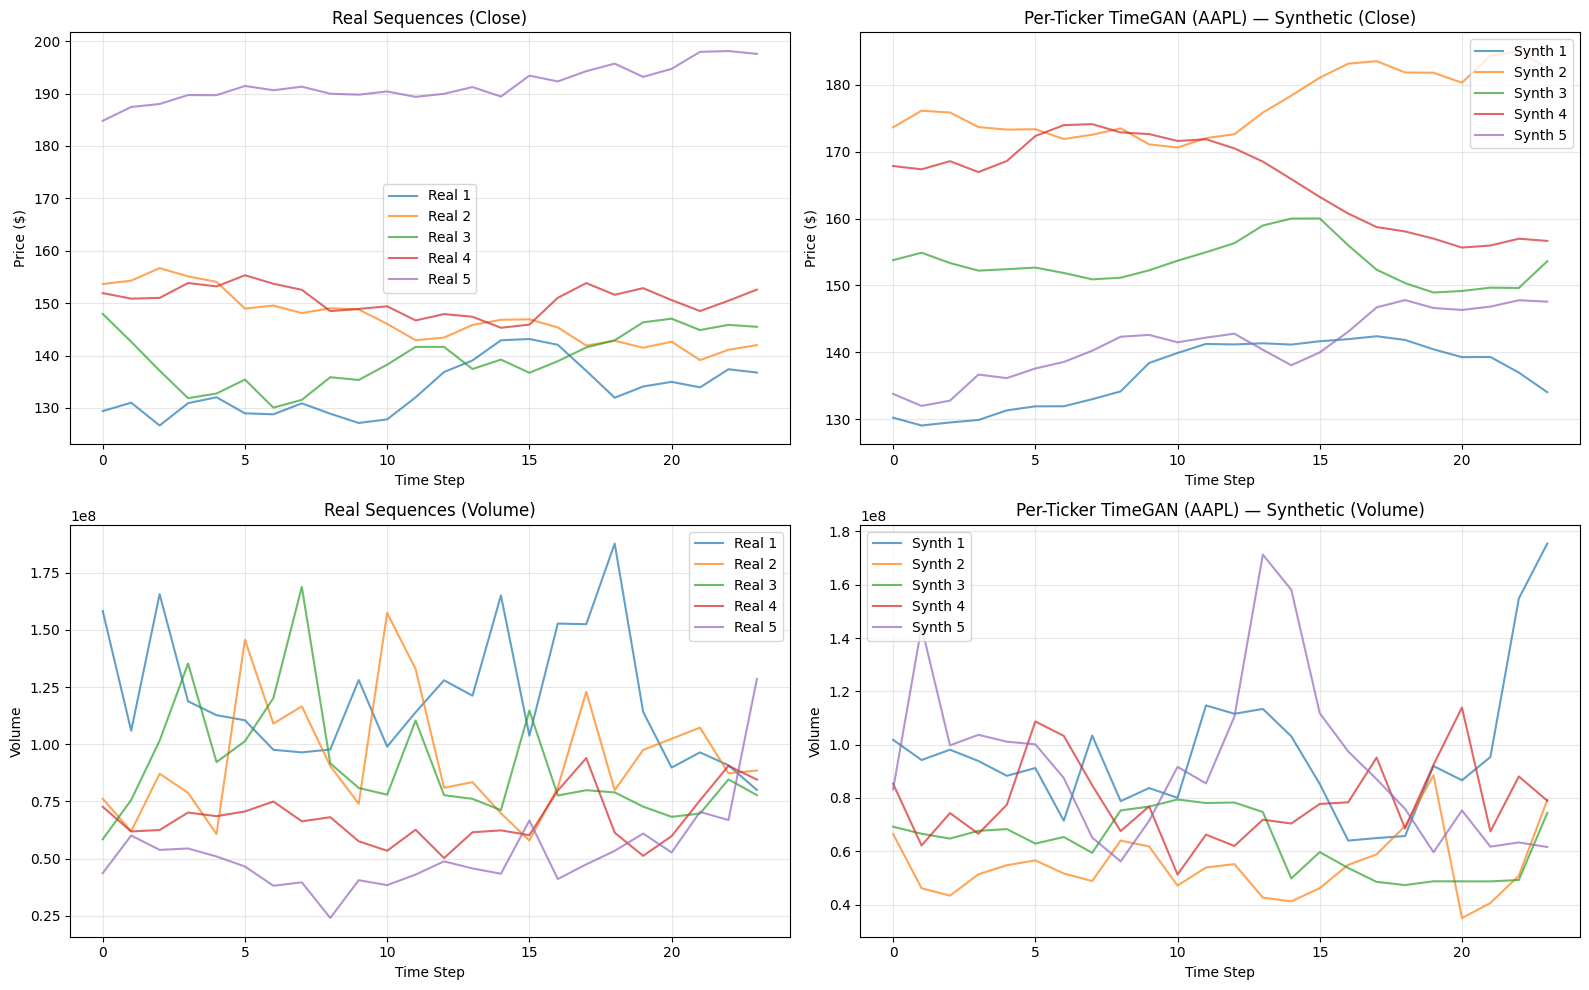

In [ ]:
# Sample sequences — 5 real vs 5 synthetic per feature (in original price space)
plot_idx = np.linspace(0, n_eval - 1, 5, dtype=int)

# Rescale to original price space for interpretability
real_plot = scaler.inverse_transform(
    real_sequences[plot_idx].reshape(-1, N_FEATURES)
).reshape(5, SEQ_LEN, N_FEATURES)
synth_plot = scaler.inverse_transform(
    synthetic_sequences[:5].reshape(-1, N_FEATURES)
).reshape(5, SEQ_LEN, N_FEATURES)

# Plot Close and Volume side by side
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i in range(5):
    axes[0, 0].plot(real_plot[i, :, 3], alpha=0.7, label=f'Real {i+1}')
axes[0, 0].set_title('Real Sequences (Close)')
axes[0, 0].set_xlabel('Time Step')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

for i in range(5):
    axes[0, 1].plot(synth_plot[i, :, 3], alpha=0.7, label=f'Synth {i+1}')
axes[0, 1].set_title(f'{MODEL_NAME} — Synthetic (Close)')
axes[0, 1].set_xlabel('Time Step')
axes[0, 1].set_ylabel('Price ($)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

for i in range(5):
    axes[1, 0].plot(real_plot[i, :, 4], alpha=0.7, label=f'Real {i+1}')
axes[1, 0].set_title('Real Sequences (Volume)')
axes[1, 0].set_xlabel('Time Step')
axes[1, 0].set_ylabel('Volume')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

for i in range(5):
    axes[1, 1].plot(synth_plot[i, :, 4], alpha=0.7, label=f'Synth {i+1}')
axes[1, 1].set_title(f'{MODEL_NAME} — Synthetic (Volume)')
axes[1, 1].set_xlabel('Time Step')
axes[1, 1].set_ylabel('Volume')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5b. Entropy Analysis

Compare the information-theoretic structure of real vs synthetic sequences using three complementary entropy measures:

- **Shannon Entropy** — measures marginal randomness of the discretised series
- **Lempel-Ziv Complexity** — captures pattern/substring diversity (mode-collapse detector)
- **Plug-in Entropy (word=2)** — captures transition / bigram structure

Values are computed after quantile-binning each series into 5 equal-frequency bins. A good generator should closely match the real data's entropy on all three measures.

In [ ]:
entropy_results = compute_entropy_metrics(real_sequences, synthetic_sequences, n_bins=5)

print("=" * 80)
print(f"  {MODEL_NAME} — Entropy Analysis (per feature)")
print("=" * 80)
print(f"  {'Feature':<15} {'Metric':<30} {'Real':>10} {'Synth':>10} {'|Δ|':>10}")
print("-" * 80)

for ch in entropy_results['shannon_real']:
    print(f"  {ch:<15} {'Shannon Entropy (bits)':<30} "
          f"{entropy_results['shannon_real'][ch]:>10.4f} "
          f"{entropy_results['shannon_synth'][ch]:>10.4f} "
          f"{entropy_results['shannon_diff'][ch]:>10.4f}")
    print(f"  {'':<15} {'Lempel-Ziv Complexity':<30} "
          f"{entropy_results['lz_real'][ch]:>10.4f} "
          f"{entropy_results['lz_synth'][ch]:>10.4f} "
          f"{entropy_results['lz_diff'][ch]:>10.4f}")
    print(f"  {'':<15} {'Plug-in Entropy (w=2, bits)':<30} "
          f"{entropy_results['plugin2_real'][ch]:>10.4f} "
          f"{entropy_results['plugin2_synth'][ch]:>10.4f} "
          f"{entropy_results['plugin2_diff'][ch]:>10.4f}")
    print("-" * 80)

print(f"\n  Mean |Δ| across features:")
print(f"    Shannon:  {entropy_results['mean_shannon_diff']:.4f}")
print(f"    LZ:       {entropy_results['mean_lz_diff']:.4f}")
print(f"    Plugin-2: {entropy_results['mean_plugin2_diff']:.4f}")

# Interpretation
mean_lz_real = np.mean(list(entropy_results['lz_real'].values()))
mean_lz_synth = np.mean(list(entropy_results['lz_synth'].values()))
lz_ratio = mean_lz_synth / max(mean_lz_real, 1e-8)
if lz_ratio < 0.85:
    print("\n  ⚠  LZ complexity is significantly LOWER than real data → possible mode collapse")
elif lz_ratio > 1.15:
    print("\n  ⚠  LZ complexity is significantly HIGHER than real data → over-random / noisy")
else:
    print("\n  ✓  LZ complexity is within 15% of real data → good pattern diversity")

  Per-Ticker TimeGAN (AAPL) — Entropy Analysis (per feature)
  Feature         Metric                               Real      Synth        |Δ|
--------------------------------------------------------------------------------
  Open            Shannon Entropy (bits)             2.3219     2.2635     0.0584
                  Lempel-Ziv Complexity              0.1761     0.1680     0.0081
                  Plug-in Entropy (w=2, bits)        3.0022     2.9255     0.0767
--------------------------------------------------------------------------------
  High            Shannon Entropy (bits)             2.3219     2.2782     0.0438
                  Lempel-Ziv Complexity              0.1734     0.1720     0.0013
                  Plug-in Entropy (w=2, bits)        2.9520     2.9767     0.0247
--------------------------------------------------------------------------------
  Low             Shannon Entropy (bits)             2.3219     2.2648     0.0571
                  Lempel-Ziv Complexity 

## 5c. Microstructure Analysis

Domain-specific financial metrics that exploit the **High / Low / Close** columns — not possible with single-feature log-return models.  
Implements the canonical RiskLabAI / de Prado (AFML Ch. 19) formulas.

- **Corwin-Schultz Spread** (snippet 19.1) — decomposes the High-Low range into a *spread* component using two-period vs one-period ranges:
  - $\beta = \text{rolling}(2)\text{.sum}\bigl[\ln(H/L)^2\bigr]$, then $\text{rolling}(w)\text{.mean}$
  - $\gamma = \bigl[\ln\bigl(\max(H_t,H_{t-1})/\min(L_t,L_{t-1})\bigr)\bigr]^2$
  - $\alpha = \frac{(\sqrt{2}-1)\sqrt{\beta}}{3-2\sqrt{2}} - \sqrt{\frac{\gamma}{3-2\sqrt{2}}}$, floored at 0
  - $S = \frac{2(e^\alpha-1)}{1+e^\alpha}$

- **Bekker-Parkinson Volatility** (snippet 19.2) — *spread-adjusted* volatility using the same $\beta, \gamma$:
  - $\sigma = \frac{(\sqrt{2}-1)\sqrt{\beta}}{d} + \sqrt{\frac{\gamma}{k_2^2 \cdot d}}$, where $k_2=\sqrt{8/\pi}$, $d=3-2\sqrt{2}$

  Per-Ticker TimeGAN (AAPL) — Microstructure Analysis
  Metric                                         Real      Synth        |Δ|
-----------------------------------------------------------------
  Bekker-Parkinson Vol                         0.1298     0.1195     0.0103
  Corwin-Schultz Spread                      0.011383   0.009903   0.001480


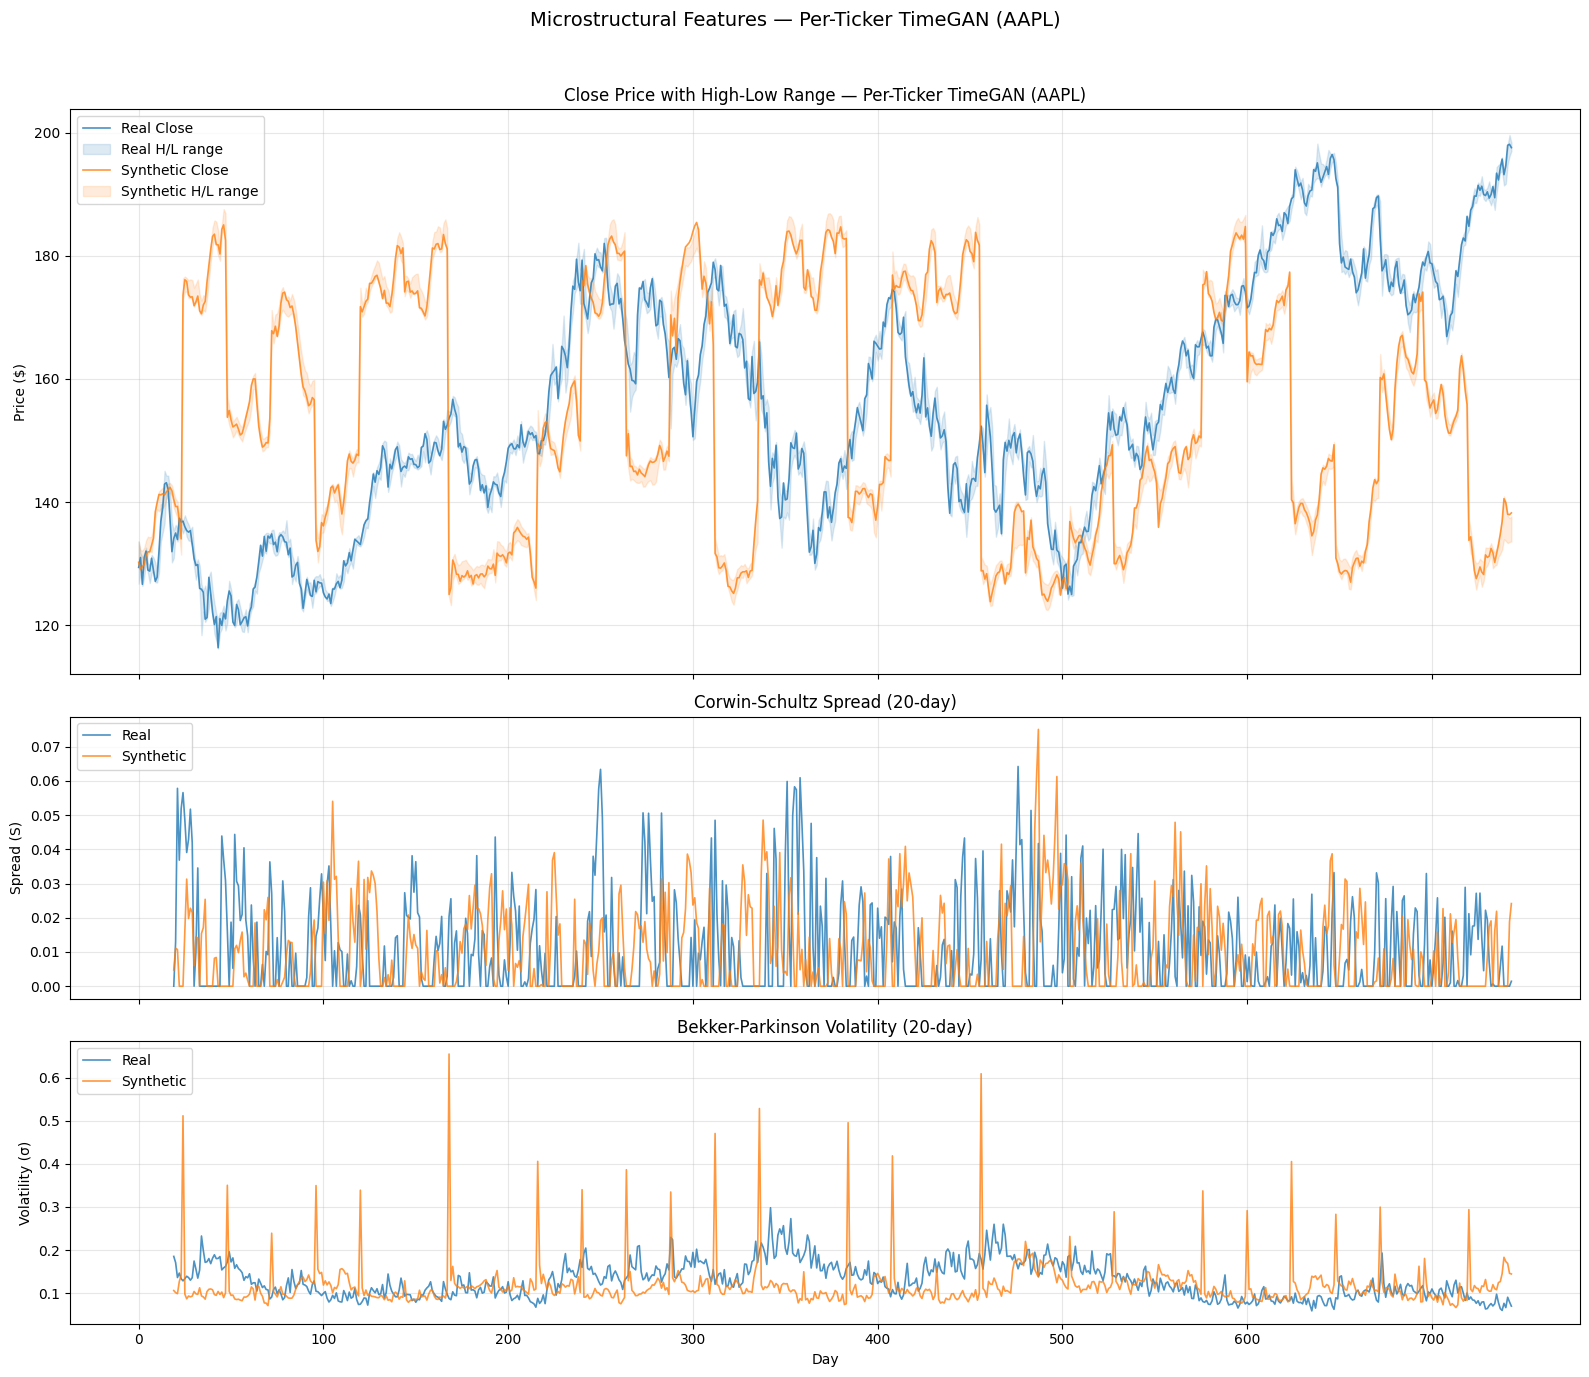


  Tail vs Microstructure Comparison:
  Metric                                    Real      Synth        |Δ|
  -----------------------------------------------------------------
  Close Kurtosis (tail risk)             -0.9014    -1.4674     0.5660
  BP Vol (spread-adjusted)                0.1298     0.1195     0.0103
  CS Spread (illiquidity)               0.011383   0.009903   0.001480


In [15]:
# Microstructure requires raw prices — inverse transform to original scale
real_prices = scaler.inverse_transform(
    real_sequences.reshape(-1, N_FEATURES)
).reshape(-1, N_FEATURES)  # flatten all windows into a single time series

synth_prices = scaler.inverse_transform(
    synthetic_sequences.reshape(-1, N_FEATURES)
).reshape(-1, N_FEATURES)

# Extract H, L, C columns (indices 1, 2, 3)
micro = compute_microstructure_metrics(
    real_high=real_prices[:, 1], real_low=real_prices[:, 2], real_close=real_prices[:, 3],
    synth_high=synth_prices[:, 1], synth_low=synth_prices[:, 2], synth_close=synth_prices[:, 3],
    window=20,
)

print("=" * 65)
print(f"  {MODEL_NAME} — Microstructure Analysis")
print("=" * 65)
print(f"  {'Metric':<40} {'Real':>10} {'Synth':>10} {'|Δ|':>10}")
print("-" * 65)
print(f"  {'Bekker-Parkinson Vol':<40} "
      f"{micro['bp_vol_real_mean']:>10.4f} "
      f"{micro['bp_vol_synth_mean']:>10.4f} "
      f"{micro['bp_vol_diff']:>10.4f}")
print(f"  {'Corwin-Schultz Spread':<40} "
      f"{micro['cs_spread_real_mean']:>10.6f} "
      f"{micro['cs_spread_synth_mean']:>10.6f} "
      f"{micro['cs_spread_diff']:>10.6f}")
print("=" * 65)

# --- 3-panel plot (RiskLabAI style) ---
bp_real  = micro['bp_vol_real']
bp_synth = micro['bp_vol_synth']
cs_real  = micro['cs_spread_real']
cs_synth = micro['cs_spread_synth']

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(16, 14), sharex=True,
    gridspec_kw={'height_ratios': [2, 1, 1]}
)

# --- Panel 1: Close price with H/L range shaded ---
ax1.plot(real_prices[:, 3], label='Real Close', color='C0', lw=1.2, alpha=0.8)
ax1.fill_between(range(len(real_prices)), real_prices[:, 2], real_prices[:, 1],
                 color='C0', alpha=0.15, label='Real H/L range')
ax1.plot(synth_prices[:, 3], label='Synthetic Close', color='C1', lw=1.2, alpha=0.8)
ax1.fill_between(range(len(synth_prices)), synth_prices[:, 2], synth_prices[:, 1],
                 color='C1', alpha=0.15, label='Synthetic H/L range')
ax1.set_title(f'Close Price with High-Low Range — {MODEL_NAME}')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# --- Panel 2: Corwin-Schultz Spread ---
ax2.plot(cs_real, label='Real', color='C0', lw=1.2, alpha=0.8)
ax2.plot(cs_synth, label='Synthetic', color='C1', lw=1.2, alpha=0.8)
ax2.set_title('Corwin-Schultz Spread (20-day)')
ax2.set_ylabel('Spread (S)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# --- Panel 3: Bekker-Parkinson Volatility ---
ax3.plot(bp_real, label='Real', color='C0', lw=1.2, alpha=0.8)
ax3.plot(bp_synth, label='Synthetic', color='C1', lw=1.2, alpha=0.8)
ax3.set_title('Bekker-Parkinson Volatility (20-day)')
ax3.set_xlabel('Day')
ax3.set_ylabel('Volatility (σ)')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)

fig.suptitle(f'Microstructural Features — {MODEL_NAME}', fontsize=14, y=1.01)
plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.show()

# --- Tail vs BP Vol comparison ---
# Compare tail risk (kurtosis) with spread-adjusted volatility
real_close_flat = real_sequences[:, :, FEATURE_NAMES.index('Close')].flatten()
synth_close_flat = synthetic_sequences[:, :, FEATURE_NAMES.index('Close')].flatten()
from scipy.stats import kurtosis as sp_kurtosis

tail_kurt_real  = sp_kurtosis(real_close_flat)
tail_kurt_synth = sp_kurtosis(synth_close_flat)

print(f"\n  Tail vs Microstructure Comparison:")
print(f"  {'Metric':<35} {'Real':>10} {'Synth':>10} {'|Δ|':>10}")
print(f"  {'-'*65}")
print(f"  {'Close Kurtosis (tail risk)':<35} {tail_kurt_real:>10.4f} {tail_kurt_synth:>10.4f} {abs(tail_kurt_real-tail_kurt_synth):>10.4f}")
print(f"  {'BP Vol (spread-adjusted)':<35} {micro['bp_vol_real_mean']:>10.4f} {micro['bp_vol_synth_mean']:>10.4f} {micro['bp_vol_diff']:>10.4f}")
print(f"  {'CS Spread (illiquidity)':<35} {micro['cs_spread_real_mean']:>10.6f} {micro['cs_spread_synth_mean']:>10.6f} {micro['cs_spread_diff']:>10.6f}")

## 6. Summary Dashboard

All scalar metrics in one table.

In [16]:
# Collect ACF RMSE means across channels
acf_ret_rmse_vals = [acf['returns'][ch]['rmse'] for ch in acf['returns']]
acf_sq_rmse_vals = [acf['squared'][ch]['rmse'] for ch in acf['squared']]
mean_acf_ret_rmse = float(np.mean(acf_ret_rmse_vals))
mean_acf_sq_rmse = float(np.mean(acf_sq_rmse_vals))

print("=" * 65)
print(f"  {MODEL_NAME} — Evaluation Summary")
print("=" * 65)
print(f"  {'Metric':<45} {'Value':>12}")
print("-" * 65)

# Distribution fidelity
print(f"  {'MMD (multi-scale RBF, mean) ↓':<45} {mmd_results['mean']:>12.6f}")
print(f"  {'Wasserstein-1 (mean) ↓':<45} {dist_results['mean_wasserstein']:>12.6f}")
print(f"  {'KS statistic (mean) ↓':<45} {dist_results['mean_ks']:>12.4f}")
print(f"  {'JS divergence ↓':<45} {js_divergence:>12.6f}")

# Temporal dynamics
print(f"  {'ACF RMSE returns (mean) ↓':<45} {mean_acf_ret_rmse:>12.6f}")
print(f"  {'ACF RMSE squared returns (mean) ↓':<45} {mean_acf_sq_rmse:>12.6f}")

# Geometric
print(f"  {'Fréchet Distance (joint) ↓':<45} {fd_results['overall_fd']:>12.6f}")
print(f"  {'DTW distance (mean) ↓':<45} {dtw_score:>12.6f}")

# Tail metrics (averaged across features)
print(f"  {'Mean diff (avg) → 0':<45} {tail_results['mean_mean_diff']:>12.6f}")
print(f"  {'Std ratio (avg) → 1.0':<45} {tail_results['mean_std_ratio']:>12.4f}")
print(f"  {'Skewness diff (avg) → 0':<45} {tail_results['mean_skew_diff']:>12.4f}")
print(f"  {'Kurtosis diff (avg) → 0':<45} {tail_results['mean_kurtosis_diff']:>12.4f}")

# Cross-correlation
print(f"  {'Cross-corr Frobenius (norm) ↓':<45} {xcorr['frobenius_normalised']:>12.4f}")

# Discriminative (MLP)
print(f"  {'MLP Disc. score ↓':<45} {disc_results['score']:>12.4f}")
print(f"  {'MLP Disc. accuracy → 0.5':<45} {disc_results['accuracy']:>12.4f}")

# GRU classifier (fidelity)
print(f"  {'GRU Disc. score ↓':<45} {gru_disc_score:>12.4f}")
print(f"  {'GRU Disc. accuracy → 0.5':<45} {gru_test_acc:>12.4f}")
print(f"  {'GRU AUC → 0.5':<45} {gru_test_auc:>12.4f}")

# TSTR (usefulness)
print(f"  {'TSTR MAE (Synth→Real) ↓':<45} {tstr_mae:>12.6f}")
print(f"  {'TRTR MAE (Real→Real) ↓':<45} {trtr_mae:>12.6f}")
print(f"  {'TSTR/TRTR ratio → 1.0':<45} {tstr_mae / trtr_mae:>12.4f}")

# Entropy (information-theoretic)
print(f"  {'Shannon Entropy |Δ| (mean) ↓':<45} {entropy_results['mean_shannon_diff']:>12.4f}")
print(f"  {'Lempel-Ziv |Δ| (mean) ↓':<45} {entropy_results['mean_lz_diff']:>12.4f}")
print(f"  {'Plug-in Entropy w=2 |Δ| (mean) ↓':<45} {entropy_results['mean_plugin2_diff']:>12.4f}")

# Microstructure
print(f"  {'BP Volatility |Δ| ↓':<45} {micro['bp_vol_diff']:>12.4f}")
print(f"  {'CS Spread |Δ| ↓':<45} {micro['cs_spread_diff']:>12.6f}")

print("=" * 65)
print(f"\n  Scale: MinMaxScaled [0,1] | Windows: non-overlapping (stride={SEQ_LEN})")
print(f"  Samples: {n_eval} real, {n_eval} synthetic | Noise: {NOISE_TYPE}")
print(f"  Features: {N_FEATURES} ({', '.join(FEATURE_NAMES)})")

  Per-Ticker TimeGAN (AAPL) — Evaluation Summary
  Metric                                               Value
-----------------------------------------------------------------
  MMD (multi-scale RBF, mean) ↓                     0.032646
  Wasserstein-1 (mean) ↓                            0.036150
  KS statistic (mean) ↓                               0.1091
  JS divergence ↓                                   0.276895
  ACF RMSE returns (mean) ↓                         0.188649
  ACF RMSE squared returns (mean) ↓                 0.199512
  Fréchet Distance (joint) ↓                        0.003553
  DTW distance (mean) ↓                            16.764375
  Mean diff (avg) → 0                               0.021393
  Std ratio (avg) → 1.0                               0.9861
  Skewness diff (avg) → 0                             0.1204
  Kurtosis diff (avg) → 0                             0.8939
  Cross-corr Frobenius (norm) ↓                       0.1253
  MLP Disc. score ↓            

NameError: name 'gru_disc_score' is not defined

## 7. Multi-Ticker Sweep (Optional)

Run the core scalar metrics across all 28 tickers and produce a comparison table.

In [ ]:
import warnings
import traceback
warnings.filterwarnings('ignore')

ALL_TICKERS = [
    'AAPL', 'AMGN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS',
    'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM',
    'MRK', 'MSFT', 'NKE', 'PG', 'TRV', 'UNH', 'V', 'VZ', 'WMT'
]

sweep_rows = []
for tic in ALL_TICKERS:
    print(f"  Evaluating {tic}...", end=" ", flush=True)
    try:
        # Load real data + scaler
        tic_df = pd.read_hdf(HDF_STORE, key=f'{tic}/real')
        tic_scaler = MinMaxScaler()
        tic_scaled = tic_scaler.fit_transform(tic_df.values).astype(np.float32)

        # Non-overlapping windows
        n_w = len(tic_scaled) // SEQ_LEN
        tic_seqs = np.array([
            tic_scaled[i * SEQ_LEN : (i + 1) * SEQ_LEN]
            for i in range(n_w)
        ], dtype=np.float32)

        # Load model & generate
        tic_model = load_model(f'../time_gan_drl_perticker/{tic}/synthetic_data.keras')
        n_e = min(N_SAMPLES, len(tic_seqs))
        Z_tic = tf.random.uniform((n_e, SEQ_LEN, N_FEATURES), 0.0, 1.0)
        tic_synth = tic_model(Z_tic, training=False).numpy()
        tic_real = tic_seqs[:n_e]

        # Core metrics
        tic_mmd = compute_mmd_per_channel(tic_real, tic_synth, num_samples=n_e)
        tic_dist = compute_distribution_per_channel(tic_real, tic_synth)
        tic_js_sim = compute_js_divergence_3d_dynamic_bins(tic_real, tic_synth)
        tic_fd = compute_frechet_distance(tic_real, tic_synth, per_channel=False)
        tic_disc = compute_discriminative_score(tic_real, tic_synth)
        tic_xcorr = compute_cross_correlation_distance(tic_real, tic_synth)
        tic_entropy = compute_entropy_metrics(tic_real, tic_synth, n_bins=5)

        # Microstructure (raw prices)
        tic_real_prices = tic_scaler.inverse_transform(
            tic_real.reshape(-1, N_FEATURES))
        tic_synth_prices = tic_scaler.inverse_transform(
            tic_synth.reshape(-1, N_FEATURES))
        tic_micro = compute_microstructure_metrics(
            tic_real_prices[:, 1], tic_real_prices[:, 2], tic_real_prices[:, 3],
            tic_synth_prices[:, 1], tic_synth_prices[:, 2], tic_synth_prices[:, 3],
        )

        sweep_rows.append({
            'Ticker': tic,
            'MMD ↓': tic_mmd['mean'],
            'Wass ↓': tic_dist['mean_wasserstein'],
            'KS ↓': tic_dist['mean_ks'],
            'JS Div ↓': (100 - tic_js_sim) / 100,
            'FD ↓': tic_fd,                                   # scalar (per_channel=False)
            'Disc ↓': tic_disc['score'],
            'XCorr ↓': tic_xcorr['frobenius_normalised'],
            'Shannon |Δ| ↓': tic_entropy['mean_shannon_diff'],
            'LZ |Δ| ↓': tic_entropy['mean_lz_diff'],
            'BP Vol |Δ| ↓': tic_micro['bp_vol_diff'],
            'CS Spread |Δ| ↓': tic_micro['cs_spread_diff'],
        })
        print("✓")

        # Clean up
        del tic_model
        tf.keras.backend.clear_session()

    except Exception as e:
        print(f"✗ ({e})")
        traceback.print_exc()
        sweep_rows.append({'Ticker': tic, 'MMD ↓': np.nan})

sweep_df = pd.DataFrame(sweep_rows).set_index('Ticker')
print(f"\n{'='*100}")
print(f"  Per-Ticker TimeGAN — 28-Ticker Sweep Summary")
print(f"{'='*100}")
print(sweep_df.to_string(float_format='{:.4f}'.format))

# Averages
print(f"\n{'─'*100}")
print(f"  Mean across tickers:")
for col in sweep_df.columns:
    print(f"    {col:<25} {sweep_df[col].mean():.4f}")

  Evaluating AAPL... Warning: Sample size may be too small for stable FD estimation. Real: 744, Fake: 744
✓
  Evaluating AMGN... Warning: Sample size may be too small for stable FD estimation. Real: 744, Fake: 744
✓
  Evaluating AXP... Warning: Sample size may be too small for stable FD estimation. Real: 744, Fake: 744
✓
  Evaluating BA... Warning: Sample size may be too small for stable FD estimation. Real: 744, Fake: 744
✓
  Evaluating CAT... Warning: Sample size may be too small for stable FD estimation. Real: 744, Fake: 744
✓
  Evaluating CRM... Warning: Sample size may be too small for stable FD estimation. Real: 744, Fake: 744
✓
  Evaluating CSCO... Warning: Sample size may be too small for stable FD estimation. Real: 744, Fake: 744
✓
  Evaluating CVX... Warning: Sample size may be too small for stable FD estimation. Real: 744, Fake: 744
✓
  Evaluating DIS... Warning: Sample size may be too small for stable FD estimation. Real: 744, Fake: 744
✓
  Evaluating GS... Warning: Sample 

: 